In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict,Literal,Optional
from pydantic import BaseModel, Field
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
review = """
I am highly disappointed with the battery performance of this phone. 
Even with light use, the percentage drops drastically fast. 
I unplugged it at 100% this morning, and it was down to 15% mid-afternoon without any gaming or heavy video streaming.
To make matters worse, charging is incredibly slow. It takes over two hours to get a full charge, 
but drains completely in less than six hours of basic web browsing and messaging. 
Having to carry a portable power bank everywhere defeats the purpose of a brand-new mobile phone. 
I would not recommend this device if you need a reliable battery.
"""

In [4]:
class Sentiment(BaseModel):
    sentiment : Literal['positive','negative'] = Field(description = "Sentiment of the review.")

In [5]:
class ReviewDiagnosis(BaseModel):
    issue_type : str = Field(description = "The issue reviewer is talking about in detail.")
    tone : str = Field(description = "The tone of the reviewer in detail.")
    urgency : str = Field(description = "The urgency of the matter for reviewer.")

In [6]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,   # Low temperature keeps the seller tone professional and consistent
    max_tokens=300     # Ensures the final response doesn't get truncated
)


diagnosis_structured_model = model.with_structured_output(ReviewDiagnosis)
sentiment_structured_model = model.with_structured_output(Sentiment)

In [7]:
class ReviewState(TypedDict):
    review : str
    sentiment : str
    response : str
    details : Optional[dict] = None

In [8]:
def find_sentiment(state : ReviewState):
    prompt = f"Find the sentiment of the review : \n {state['review']}"
    
    response = sentiment_structured_model.invoke(prompt)
    
    return {"sentiment":response.sentiment}

def run_diagnosis(state : ReviewState):
    prompt = f"Fetch the issue, tone and urgency from the given review for diagnosis : \n {state['review']}."
    
    details = diagnosis_structured_model.invoke(prompt)
    
    return {"details":dict(details)}

def response_to_negative(state : ReviewState):
    prompt = f"""You are the seller of the product. Generate an appropriate response for the negative review.
    CRITICAL INSTRUCTION: Output ONLY the final customer response. Do NOT include any thoughts, reasoning, <think> tags, or explanations. Start directly with the greeting.
    Review: 
    {state['review']} 
    Diagnosis Details: 
    {state['details']}"""
    
    response = model.invoke(prompt)
    
    return {"response":response.content}

def response_to_positive(state : ReviewState):
    prompt = f"""You are the seller of the product. Generate an appropriate response to the given positive review.
    CRITICAL INSTRUCTION: Output ONLY the final customer response. Do NOT include any thoughts, reasoning, <think> tags, or explanations. Start directly with the greeting.
    Review: 
    {state['review']}"""
    
    response = model.invoke(prompt)
    
    return {"response":response.content}


def check_condition(state : ReviewState) -> Literal["run_diagnosis","response_to_positive"]:
    
    if state["sentiment"] == 'positive':
        return "response_to_positive"
    else:
        return "run_diagnosis"

In [9]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment",find_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("response_to_negative",response_to_negative)
graph.add_node("response_to_positive",response_to_positive)

graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_condition)
graph.add_edge("run_diagnosis","response_to_negative")
graph.add_edge("response_to_negative",END)
graph.add_edge("response_to_positive",END)

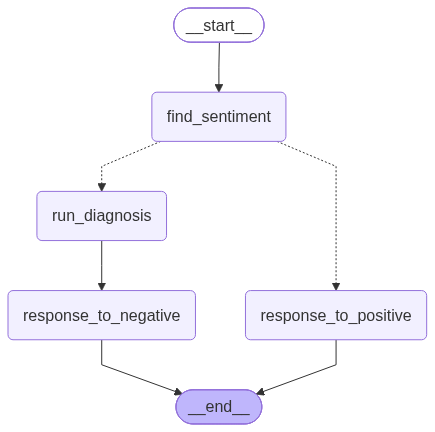

In [10]:
workflow = graph.compile()
workflow

In [11]:
initial_state = {"review":review}

workflow.invoke(initial_state)

{'review': '\nI am highly disappointed with the battery performance of this phone. \nEven with light use, the percentage drops drastically fast. \nI unplugged it at 100% this morning, and it was down to 15% mid-afternoon without any gaming or heavy video streaming.\nTo make matters worse, charging is incredibly slow. It takes over two hours to get a full charge, \nbut drains completely in less than six hours of basic web browsing and messaging. \nHaving to carry a portable power bank everywhere defeats the purpose of a brand-new mobile phone. \nI would not recommend this device if you need a reliable battery.\n',
 'sentiment': 'negative',
 'response': 'Hi [Customer Name],\n\nThank you for taking the time to share your experience, and I’m truly sorry to hear about the battery issues you’ve encountered with your new phone. We understand how frustrating rapid drain and slow charging can be, especially when you rely on your device throughout the day.\n\nTo help resolve this as quickly as p